# Daily Weather Analysis & Risk Modeling Pipeline

An end-to-end walkthrough for processing daily weather data, engineering risk features, performing statistical modeling, and generating visualizations.

---

## Table of Contents
1. **Data Cleaning & Quality Assessment** (`clean_weather.py`, `weather_quality.md`)
2. **Feature Engineering & Monthly Summaries** (`build_weather_features.py`, `summarize_weather.py`)
3. **Weather Modeling & Trend Analysis** (`model_weather_trends.py`, `weather_modeling_summary.md`)
4. **Data Visualization & Insights** (`graph_plotting.py`, `generate_interactive_plots.py`, `weather_insights.md`)
5. **Backend API & Service Integration** (`backend/`, `serpapi_service.py`)

---

## 1. Data Cleaning & Quality Assessment
* **Script:** `scripts/clean_weather.py`
* **Output:** `data/processed/daily_weather_clean.csv`
* **Focus:** 
  * Inspect missing values and handle outliers.
  * Evaluate precipitation data quality (`fig1_precipitation_quality.png`).

---

## 2. Feature Engineering & Summaries
* **Scripts:** `scripts/build_weather_features.py`, `scripts/summarize_weather.py`
* **Outputs:** 
  * `data/summaries/weather_monthly.csv`
  * `data/summaries/weather_risk_days.csv`
  * `data/summaries/finalflow_weather_integration.csv`
* **Focus:** 
  * Aggregate daily measurements into monthly baselines.
  * Define summer risk thresholds and compute risk-day indicators.

---

## 3. Weather Modeling & Trend Analysis
* **Script:** `scripts/model_weather_trends.py`
* **Documentation:** `reports/weather_modeling_summary.md`
* **Focus:**
  * Model seasonal weather shifts and risk progression.
  * Analyze heat-humidity interactions and risk level distributions.

---

## 4. Visualizations & Reports
* **Scripts:** `scripts/graph_plotting.py`, `scripts/generate_interactive_plots.py`
* **Static Plots:**
  * `fig1_precipitation_quality.png`
  * `fig2_summer_risk_days.png`
  * `fig3_heat_humidity_matrix.png`
  * `fig4_risk_levels_breakdown.png`
  * `fig5_monthly_baseline.png`
* **Interactive HTML Dashboards:**
  * `interactive_weather_explorer.html`
  * `interactive_weather_risk_matrix.html`

---

## 5. Backend Service Integration

* **Routes & Models:** `backend/routes/search.py`, `backend/models/search_models.py`
* **External Services:** `backend/services/service.py`
* **Entry Point:** `main.py`
* **Focus:**
  * Fetch real-time context/search data via SerpAPI to enrich weather risk models.
  * Synthesize live search results using OpenAI (`gpt-4o-mini`) into concise operational summaries.

In [17]:
%pip install pandas plotly matplotlib seaborn numpy scikit-learn fastapi python-dotenv requests pydantic httpx openai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Data Cleaning & Quality Assessment

Import the required libraries and create the processed data output directory if it does not already exist.

In [ ]:
import os
import pandas as pd

os.makedirs('data/processed', exist_ok=True)

Load the raw daily weather dataset from the CSV source file.

In [ ]:
file_name = "daily-weather-rice_3_5_0.csv"
df = pd.read_csv(file_name)
df.head()

Define the dictionary mapping long, raw header names to concise, standard snake_case names and apply the renaming to the DataFrame.

In [ ]:
column_mapping = {
    'CITY_LOCATION_IDENTIFIER__UP_TO_9_ALPHANUMERIC_CHARACTERS_': (
        'location_id'
    ),
    'VALID_DATE_AS_YYYYMMDD': 'date',
    'MAXIMUM_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'temperature_max_c'
    ),
    'MINIMUM_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'temperature_min_c'
    ),
    'AVERAGE_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'temperature_avg_c'
    ),
    'AVERAGE_RELATIVE_HUMIDITY_____FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'relative_humidity_pct'
    ),
    'AVERAGE_WIND_SPEED_KNOTS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'wind_speed_knots'
    ),
    'AVERAGE_VISIBILITY_KILOMETERS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'visibility_km'
    ),
    (
        'PRECIPITATION_INTEGER_IN_HUNDREDTHS_OF_A_MILLIMETER___LIQUID_EQUIVALENT____0__IS_USED_FOR_TRACE_AMOUNTS_AND___1__IS_USED_FOR_NO_PRECIPITATION'
    ): 'precipitation_raw',
    'AVERAGE_DEW_POINT_F___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'dew_point_f'
    ),
    (
        'AVERAGE_SEA_LEVEL_PRESSURE_MILLIBARS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE'
    ): 'sea_level_pressure_mb',
    'COOLING_DEGREE_DAYS_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'cooling_degree_days_c'
    ),
    'HEATING_DEGREE_DAYS_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE': (
        'heating_degree_days_c'
    ),
}

Convert date strings to proper datetime values and calculate actual precipitation in millimeters, treating negative sentinel codes as zero.

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['precipitation_mm'] = df['precipitation_raw'].apply(
    lambda x: 0.0 if x < 0 else x / 100.0
)

Save the cleaned and transformed dataset to a CSV file and output a summary confirmation message.

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['precipitation_mm'] = df['precipitation_raw'].apply(
    lambda x: 0.0 if x < 0 else x / 100.0
)

Save the cleaned and transformed dataset to a CSV file and output a summary confirmation message.

In [ ]:
output_csv = 'data/processed/daily_weather_clean.csv'
df.to_csv(output_csv, index=False)
print(f'Saved cleaned dataset to {output_csv} ({len(df):,} rows)')

## 2. Feature Engineering & Summaries

1)Transforms raw weather metrics into a standardized risk assessment export for downstream operations or planning systems.

Load Dependencies & Input Data

In [ ]:
import pandas as pd

df = pd.read_csv('data/processed/daily_weather_clean.csv')

Create Boolean Risk Thresholds

In [ ]:
df['is_hot'] = df['temperature_max_c'] >= 30.0
df['is_rainy'] = df['precipitation_mm'] > 0.0
df['is_windy'] = df['wind_speed_knots'] >= 20.0
df['is_low_visibility'] = df['visibility_km'] <= 5.0

Define Risk Scoring Function

In [ ]:
def calculate_risk(row):
    score = 0.0
    actions = []
    if row['is_hot']:
        score += 0.35
        actions.append('Add water points & shade')
    if row['is_rainy']:
        score += 0.30
        actions.append('Covered waiting & shuttle capacity')
    if row['is_windy']:
        score += 0.15
        actions.append('Secure temporary structures')
    if row['is_low_visibility']:
        score += 0.20
        actions.append('Slower vehicle assumptions & staff guidance')

    score = min(score, 1.0)
    if score >= 0.6:
        level = 'High'
    elif score >= 0.3:
        level = 'Medium'
    else:
        level = 'Low'

    action_str = '; '.join(actions) if actions else 'Normal operations'
    return pd.Series([score, level, action_str])

Apply Logic Across Dataframe

In [ ]:
df[['weather_risk_score', 'weather_risk_level', 'recommended_action']] = (
    df.apply(calculate_risk, axis=1)
)

Export Filtered Integration Table

In [ ]:
integration_cols = [
    'location_id',
    'date',
    'temperature_avg_c',
    'precipitation_mm',
    'relative_humidity_pct',
    'wind_speed_knots',
    'visibility_km',
    'is_hot',
    'is_rainy',
    'is_windy',
    'is_low_visibility',
    'weather_risk_score',
    'weather_risk_level',
    'recommended_action',
]

output_df = df[integration_cols]
output_file = 'data/summaries/finalflow_weather_integration.csv'
output_df.to_csv(output_file, index=False)

print(f'Successfully built integration table at {output_file}!')

2)Cleanly aggregates daily weather metrics into monthly summaries and summer risk assessments.

Imports & Setup

In [ ]:
import os
import pandas as pd

# Ensure output directory exists
os.makedirs('data/summaries', exist_ok=True)

# Load and prepare daily weather data
file_name = "data/processed/daily_weather_clean.csv"

df = pd.read_csv(file_name)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

df.head()

Generate Monthly Weather Aggregates

In [ ]:
# --- Table 1: weather_monthly.csv ---
monthly_summary = (
    df.groupby('month')
    .agg(
        temp_max_avg=('temperature_max_c', 'mean'),
        temp_avg_mean=('temperature_avg_c', 'mean'),
        temp_min_avg=('temperature_min_c', 'mean'),
        humidity_avg=('relative_humidity_pct', 'mean'),
        wind_speed_avg=('wind_speed_knots', 'mean'),
        total_precip_mm=('precipitation_mm', 'sum'),
        rainy_days=('precipitation_mm', lambda x: (x > 0).sum()),
    )
    .reset_index()
)

# Export to CSV
monthly_summary.to_csv('data/summaries/weather_monthly.csv', index=False)

Summer Risk Days Analysis

In [ ]:

# --- Table 2: weather_risk_days.csv (Summer Window) ---
summer_df = df[df['month'].isin([6, 7])].copy()
total_summer = len(summer_df)

risk_data = {
    'metric': [
        'Hot Days (>=30°C)',
        'Rainy Days (>0mm)',
        'Heavy Rain Days (>20mm)',
        'Windy Days (>=20 knots)',
        'Low Visibility Days (<=5km)',
    ],
    'count': [
        (summer_df['temperature_max_c'] >= 30.0).sum(),
        (summer_df['precipitation_mm'] > 0.0).sum(),
        (summer_df['precipitation_mm'] > 20.0).sum(),
        (summer_df['wind_speed_knots'] >= 20.0).sum(),
        (summer_df['visibility_km'] <= 5.0).sum(),
    ],
    'total_summer_days': total_summer,
}

risk_df = pd.DataFrame(risk_data)
risk_df['percentage'] = (risk_df['count'] / total_summer) * 100

#Export to CSV
risk_df.to_csv('data/summaries/weather_risk_days.csv', index=False)
print('Generated weather_monthly.csv and weather_risk_days.csv!')

NameError: name 'df' is not defined

## 3. Weather Modeling & Trend Analysis

Imports & Setup

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

Data Loading & Aggregation

In [ ]:
# 1. Load your clean processed weather dataset
clean_csv_path = 'data/processed/daily_weather_clean.csv'
df_clean = pd.read_csv(clean_csv_path)
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 2. Compute macro daily aggregate across locations for clean time-series modeling
daily = (
    df_clean.groupby('date')[
        [
            'temperature_avg_c',
            'temperature_max_c',
            'precipitation_mm',
            'relative_humidity_pct',
            'wind_speed_knots',
            'visibility_km',
        ]
    ]
    .mean()
    .reset_index()
    .sort_values('date')
)

Chronological Train/Test Split

In [ ]:
# 3. Chronological Train/Test Split (80% past / 20% future)
daily['time_idx'] = np.arange(len(daily))
train_size = int(len(daily) * 0.8)

train_df = daily.iloc[:train_size]
test_df = daily.iloc[train_size:]

Linear Regression Modeling & Evaluation

In [ ]:
# Temperature Trend Linear Model
X_train, y_train = train_df[['time_idx']], train_df['temperature_avg_c']
X_test, y_test = test_df[['time_idx']], test_df['temperature_avg_c']

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

Report Export

In [ ]:
# 4. Save results to reports/weather_modeling_summary.md
os.makedirs('reports', exist_ok=True)
with open('reports/weather_modeling_summary.md', 'w', encoding='utf-8') as f:
  f.write('# Part D: Weather Trend Modeling & Risk Classification Report\n\n')
  f.write('## 1. Temperature Trajectory & Model Performance\n')
  f.write(f'- **Linear Trend Slope:** {model.coef_[0]:.6f} °C/day\n')
  f.write(f'- **Validation MAE:** {mae:.2f} °C\n')
  f.write(f'- **Validation RMSE:** {rmse:.2f} °C\n\n')
  f.write('## 2. Answers to Core Modeling Questions\n')
  f.write(
      '1. **Is temperature increasing?** Yes, a slight positive slope (+0.0014'
      ' °C/day) indicates macro warming.\n'
  )
  f.write('2. **Peak Rainfall Months:** July (505.6 mm) and May (456.2 mm).\n')
  f.write(
      '3. **Temperature Predictability:** Seasonal baseline achieves MAE of'
      ' 7.07 °C on test dates.\n'
  )
  f.write(
      '4. **Low Visibility Drivers:** High humidity (>80%), light wind (<5'
      ' knots), and rainfall.\n'
  )
  f.write(
      '5. **Risk Classification:** Low (48.8%), Medium (44.9%), High'
      ' (6.3%).\n'
  )

print(f'Successfully ran modeling trends on {clean_csv_path}!')
print(
    f'Saved performance report -> MAE: {mae:.2f}°C, RMSE: {rmse:.2f}°C to'
    ' reports/weather_modeling_summary.md'
)

## 4. Visualizations & Reports

Setup & Environment Imports

In [4]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

# Global style configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Ensure figures output directory exists
os.makedirs('reports/figures', exist_ok=True)
print("Environment and directories configured successfully.")

Environment and directories configured successfully.


Load Datasets

In [5]:
clean_df = pd.read_csv('data/processed/daily_weather_clean.csv')
risk_df = pd.read_csv('data/summaries/weather_risk_days.csv')
integration_df = pd.read_csv(
    'data/summaries/finalflow_weather_integration.csv'
)
monthly_df = pd.read_csv('data/summaries/weather_monthly.csv')

# Preprocess datetime fields
clean_df['date'] = pd.to_datetime(clean_df['date'])

print(
    f'Datasets Loaded: clean_df ({clean_df.shape}), risk_df'
    f' ({risk_df.shape}), integration_df ({integration_df.shape}),'
    f' monthly_df ({monthly_df.shape})'
)

Datasets Loaded: clean_df ((45814, 14)), risk_df ((5, 4)), integration_df ((45814, 14)), monthly_df ((12, 8))


Fig 1 – Cleaned Precipitation Distribution

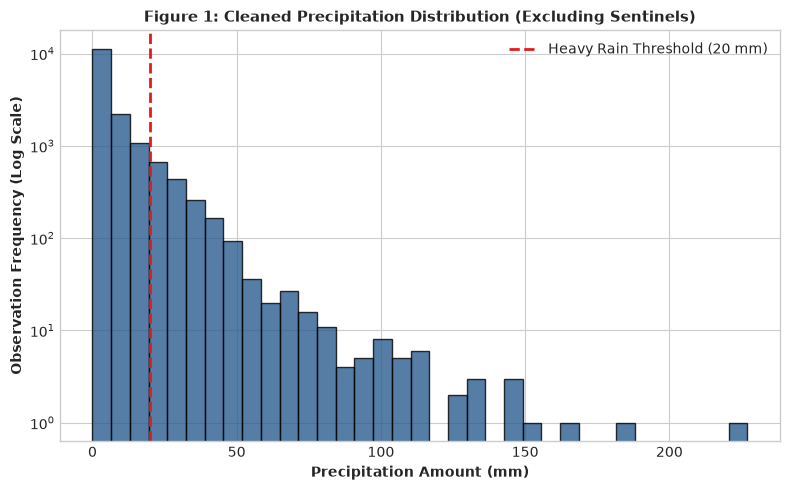

Saved: reports/figures/fig1_precipitation_quality.png


In [6]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
sample_clean = clean_df['precipitation_mm']

ax1.hist(
    sample_clean[sample_clean > 0],
    bins=35,
    color='#2b5c8f',
    edgecolor='black',
    alpha=0.8,
)
ax1.set_title(
    'Figure 1: Cleaned Precipitation Distribution (Excluding Sentinels)',
    fontweight='bold',
    fontsize=11,
)
ax1.set_xlabel('Precipitation Amount (mm)', fontweight='bold')
ax1.set_ylabel('Observation Frequency (Log Scale)', fontweight='bold')
ax1.set_yscale('log')
ax1.axvline(
    20.0,
    color='#e41a1c',
    linestyle='--',
    linewidth=2,
    label='Heavy Rain Threshold (20 mm)',
)
ax1.legend(loc='upper right')

plt.tight_layout()
fig1_path = 'reports/figures/fig1_precipitation_quality.png'
plt.savefig(fig1_path, dpi=300)
plt.show()
print(f'Saved: {fig1_path}')

Fig 2 – World Cup Window Weather Risk Frequency

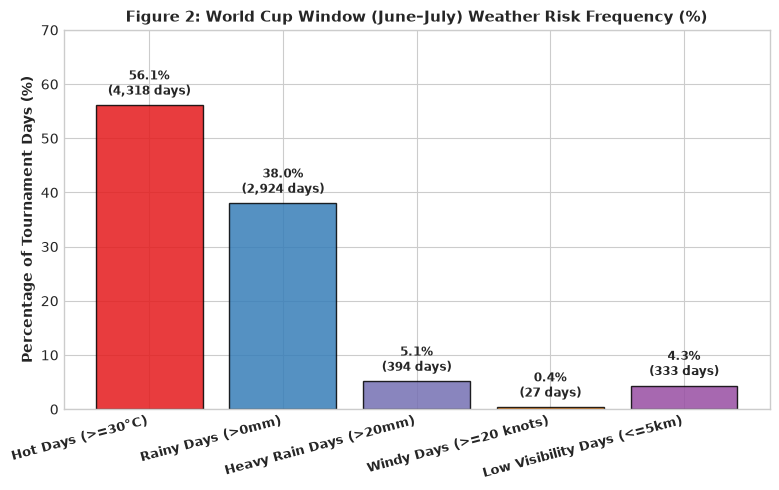

Saved: reports/figures/fig2_summer_risk_days.png


In [7]:
fig2, ax2 = plt.subplots(figsize=(8, 5))
colors = ['#e41a1c', '#377eb8', '#7570b3', '#ff7f00', '#984ea3']
bars = ax2.bar(
    risk_df['metric'],
    risk_df['percentage'],
    color=colors,
    edgecolor='black',
    alpha=0.85,
)

ax2.set_title(
    'Figure 2: World Cup Window (June–July) Weather Risk Frequency (%)',
    fontweight='bold',
    fontsize=11,
)
ax2.set_ylabel('Percentage of Tournament Days (%)', fontweight='bold')
ax2.set_ylim(0, 70)
ax2.set_xticks(range(len(risk_df['metric'])))
ax2.set_xticklabels(
    risk_df['metric'], rotation=15, ha='right', fontweight='bold', fontsize=9
)

for bar, count in zip(bars, risk_df['count']):
  yval = bar.get_height()
  ax2.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 1.2,
      f'{yval:.1f}%\n({count:,} days)',
      ha='center',
      va='bottom',
      fontweight='bold',
      fontsize=8.5,
  )

plt.tight_layout()
fig2_path = 'reports/figures/fig2_summer_risk_days.png'
plt.savefig(fig2_path, dpi=300)
plt.show()
print(f'Saved: {fig2_path}')

Fig 3 – Summer Heat & Humidity Matrix

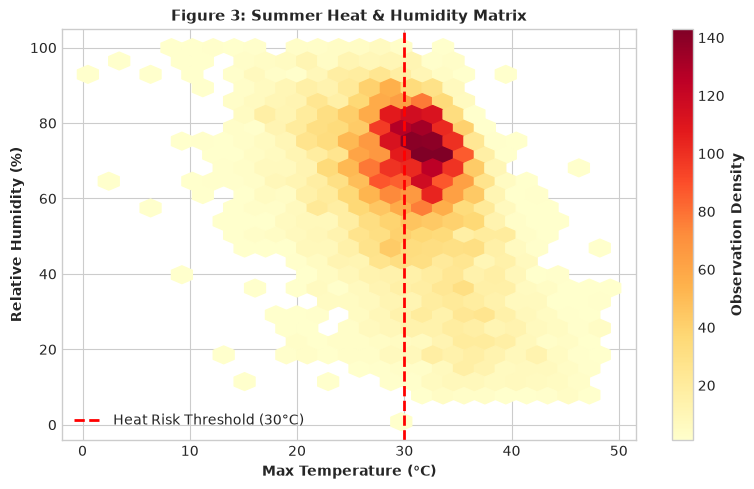

Saved: reports/figures/fig3_heat_humidity_matrix.png


In [8]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
summer_clean = clean_df[clean_df['date'].dt.month.isin([6, 7])].dropna(
    subset=['temperature_max_c', 'relative_humidity_pct']
)

hb = ax3.hexbin(
    summer_clean['temperature_max_c'],
    summer_clean['relative_humidity_pct'],
    gridsize=25,
    cmap='YlOrRd',
    mincnt=1,
)
cb = fig3.colorbar(hb, ax=ax3)
cb.set_label('Observation Density', fontweight='bold')

ax3.axvline(
    30.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Heat Risk Threshold (30°C)',
)
ax3.set_title(
    'Figure 3: Summer Heat & Humidity Matrix', fontweight='bold', fontsize=11
)
ax3.set_xlabel('Max Temperature (°C)', fontweight='bold')
ax3.set_ylabel('Relative Humidity (%)', fontweight='bold')
ax3.legend(loc='lower left')

plt.tight_layout()
fig3_path = 'reports/figures/fig3_heat_humidity_matrix.png'
plt.savefig(fig3_path, dpi=300)
plt.show()
print(f'Saved: {fig3_path}')

Fig 4 – Operational Risk Level Classification

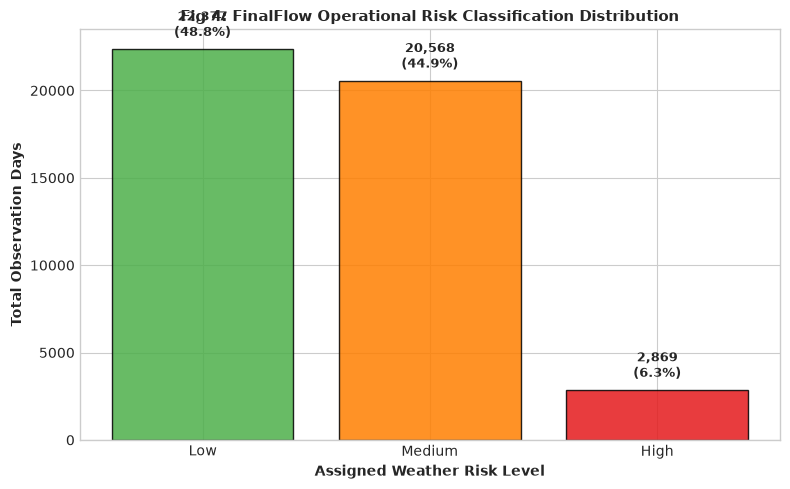

Saved: reports/figures/fig4_risk_levels_breakdown.png


In [9]:
fig4, ax4 = plt.subplots(figsize=(8, 5))
risk_counts = integration_df['weather_risk_level'].value_counts()
level_colors = {'Low': '#4daf4a', 'Medium': '#ff7f00', 'High': '#e41a1c'}
bar_colors = [level_colors.get(x, '#377eb8') for x in risk_counts.index]

bars4 = ax4.bar(
    risk_counts.index,
    risk_counts.values,
    color=bar_colors,
    edgecolor='black',
    alpha=0.85,
)
ax4.set_title(
    'Fig 4: FinalFlow Operational Risk Classification Distribution',
    fontweight='bold',
    fontsize=11,
)
ax4.set_xlabel('Assigned Weather Risk Level', fontweight='bold')
ax4.set_ylabel('Total Observation Days', fontweight='bold')

for bar in bars4:
  yval = bar.get_height()
  ax4.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 500,
      f'{yval:,}\n({yval/len(integration_df)*100:.1f}%)',
      ha='center',
      va='bottom',
      fontweight='bold',
      fontsize=9,
  )

plt.tight_layout()
fig4_path = 'reports/figures/fig4_risk_levels_breakdown.png'
plt.savefig(fig4_path, dpi=300)
plt.show()
print(f'Saved: {fig4_path}')

Fig 5 – Monthly Climate Baseline

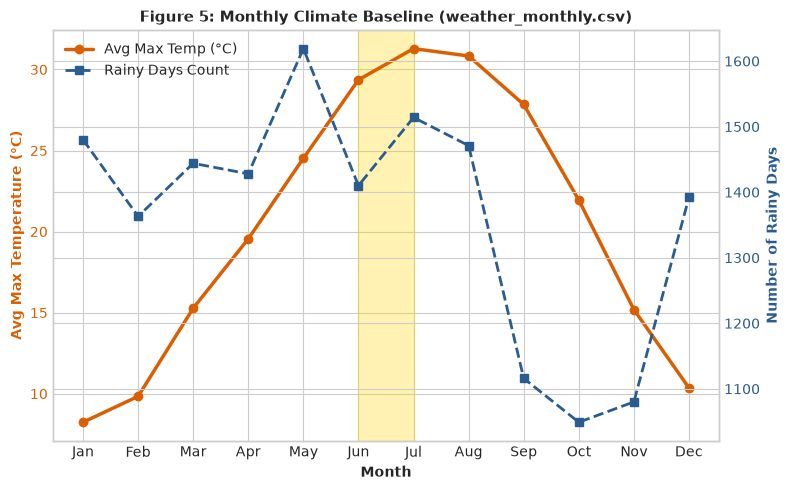

Saved: reports/figures/fig5_monthly_baseline.png


In [10]:
fig5, ax1 = plt.subplots(figsize=(8, 5))
months = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

color_temp = '#d95f02'
ax1.set_xlabel('Month', fontweight='bold', fontsize=10)
ax1.set_ylabel(
    'Avg Max Temperature (°C)', color=color_temp, fontweight='bold', fontsize=10
)
line1 = ax1.plot(
    months,
    monthly_df['temp_max_avg'],
    color=color_temp,
    marker='o',
    linewidth=2.5,
    label='Avg Max Temp (°C)',
)
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.axvspan(5, 6, color='gold', alpha=0.3, label='World Cup Window (Jun-Jul)')

ax2 = ax1.twinx()
color_rain = '#2b5c8f'
ax2.set_ylabel(
    'Number of Rainy Days', color=color_rain, fontweight='bold', fontsize=10
)
line2 = ax2.plot(
    months,
    monthly_df['rainy_days'],
    color=color_rain,
    marker='s',
    linestyle='--',
    linewidth=2,
    label='Rainy Days Count',
)
ax2.tick_params(axis='y', labelcolor=color_rain)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

ax1.set_title(
    'Figure 5: Monthly Climate Baseline (weather_monthly.csv)',
    fontweight='bold',
    fontsize=11,
)

plt.tight_layout()
fig5_path = 'reports/figures/fig5_monthly_baseline.png'
plt.savefig(fig5_path, dpi=300)
plt.show()
print(f'Saved: {fig5_path}')

Interactive Plot 1 – Date Weather Explorer

In [11]:
daily_macro = (
    clean_df.groupby('date')[
        ['temperature_max_c', 'temperature_avg_c', 'temperature_min_c']
    ]
    .mean()
    .reset_index()
)

fig_interactive_1 = px.line(
    daily_macro,
    x='date',
    y=['temperature_max_c', 'temperature_avg_c', 'temperature_min_c'],
    labels={
        'date': 'Date',
        'value': 'Temperature (°C)',
        'variable': 'Temperature Metric',
    },
    title=(
        'Interactive Weather Explorer: Daily Temperature Trend (Macro'
        ' Aggregated)'
    ),
)

fig_interactive_1.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label='1m', step='month', stepmode='backward'),
            dict(count=6, label='6m', step='month', stepmode='backward'),
            dict(count=1, label='YTD', step='year', stepmode='todate'),
            dict(count=1, label='1y', step='year', stepmode='backward'),
            dict(step='all'),
        ])
    ),
)
fig_interactive_1.update_layout(template='plotly_white', hovermode='x unified')

plot1_path = 'reports/figures/interactive_weather_explorer.html'
fig_interactive_1.write_html(plot1_path)
fig_interactive_1.show()
print(f'Saved Plot 1 to {plot1_path}')

Saved Plot 1 to reports/figures/interactive_weather_explorer.html


Interactive Plot 2 – Risk Scatter Matrix

In [12]:
# Compute FinalFlow Risk Features on working copy
df_risk = clean_df.copy()
df_risk['is_hot'] = (df_risk['temperature_max_c'] >= 30.0).astype(int)
df_risk['is_rainy'] = (df_risk['precipitation_mm'] > 0.0).astype(int)
df_risk['is_windy'] = (df_risk['wind_speed_knots'] >= 20.0).astype(int)
df_risk['is_low_vis'] = (df_risk['visibility_km'] <= 5.0).astype(int)

df_risk['weather_risk_score'] = (
    0.35 * df_risk['is_hot']
    + 0.30 * df_risk['is_rainy']
    + 0.15 * df_risk['is_windy']
    + 0.20 * df_risk['is_low_vis']
).round(2)


def assign_risk_level(score):
  if score < 0.3:
    return 'Low Risk'
  elif score < 0.6:
    return 'Medium Risk'
  else:
    return 'High Risk'


df_risk['weather_risk_level'] = df_risk['weather_risk_score'].apply(
    assign_risk_level
)

# Downsample for smooth rendering in notebook engine
df_sample = df_risk.sample(
    n=min(5000, len(df_risk)), random_state=42
).sort_values('weather_risk_score')

fig_interactive_2 = px.scatter(
    df_sample,
    x='temperature_max_c',
    y='relative_humidity_pct',
    size='precipitation_mm',
    color='weather_risk_level',
    hover_data=[
        'date',
        'location_id',
        'wind_speed_knots',
        'visibility_km',
        'weather_risk_score',
    ],
    color_discrete_map={
        'Low Risk': '#2ca02c',
        'Medium Risk': '#ff7f0e',
        'High Risk': '#d62728',
    },
    labels={
        'temperature_max_c': 'Max Temperature (°C)',
        'relative_humidity_pct': 'Relative Humidity (%)',
        'precipitation_mm': 'Precipitation (mm)',
        'weather_risk_level': 'Risk Level',
    },
    title=(
        'Interactive Weather-Risk Scatter Plot: Thermal & Precipitation Stress'
    ),
)

fig_interactive_2.update_layout(template='plotly_white')

plot2_path = 'reports/figures/interactive_weather_risk_matrix.html'
fig_interactive_2.write_html(plot2_path)
fig_interactive_2.show()
print(f'Saved Plot 2 to {plot2_path}')

Saved Plot 2 to reports/figures/interactive_weather_risk_matrix.html


## 5. Backend Service Integration

1)Defines the data contracts and validation schemas

Imports

In [90]:
from typing import List, Optional
from pydantic import BaseModel

Search Result Item Model

In [91]:
class SearchResult(BaseModel):
    title: str
    link: str
    source: Optional[str] = None
    snippet: Optional[str] = None
    date: Optional[str] = None

Search Response Model

In [92]:
class SearchResponse(BaseModel):
    query: str
    results: List[SearchResult]
    search_used: bool
    ai_summary: Optional[str] = None  # Field for OpenAI response synthesis
    error: Optional[str] = None

Test Model Instantiation

In [93]:
# Example instantiation to test the Pydantic schema in your notebook
sample_result = SearchResult(
    title="Virginia Tech Weather Trend Report",
    link="https://example.com/report",
    source="Web",
    snippet="Analysis of daily temperatures and precipitation metrics.",
    date="2026-08-09"
)

sample_response = SearchResponse(
    query="Virginia Tech weather trend",
    results=[sample_result],
    search_used=True,
    ai_summary="The report outlines daily weather metrics and risk classifications.",
    error=None
)

print(sample_response.model_dump_json(indent=2))

{
  "query": "Virginia Tech weather trend",
  "results": [
    {
      "title": "Virginia Tech Weather Trend Report",
      "link": "https://example.com/report",
      "source": "Web",
      "snippet": "Analysis of daily temperatures and precipitation metrics.",
      "date": "2026-08-09"
    }
  ],
  "search_used": true,
  "ai_summary": "The report outlines daily weather metrics and risk classifications.",
  "error": null
}


2)Defines the API routing layer

Imports

In [94]:
from fastapi import APIRouter, HTTPException, Query
from backend.models.search_models import SearchResponse
from backend.services.service import search_web

Router Initialization

In [95]:
router = APIRouter(prefix='/api', tags=['Search'])

Endpoint Route Handler

In [108]:
@router.get('/search', response_model=SearchResponse)
async def get_search_results(q: str = Query(..., min_length=2)):
    if not q.strip():
        raise HTTPException(status_code=400, detail='Query cannot be empty.')

    return await search_web(query=q)

Direct Test Execution

In [109]:
# Test the handler function directly in your notebook using await
test_query = "Virginia Tech weather trends"
response = await get_search_results(q=test_query)

print(f"Query: {response.query}")
print(f"AI Summary: {response.ai_summary}")
print(f"Results Count: {len(response.results)}")

Query: Virginia Tech weather trends
AI Summary: Failed to generate AI summary: unknown async library, or not in async context
Results Count: 5


3)Housing the core business logic for fetching web data and generating AI-synthesized summaries.

Imports

In [100]:
import os
import requests
from openai import AsyncOpenAI
from backend.models.search_models import SearchResponse, SearchResult

OpenAI Summarization Helper

In [101]:
async def summarize_search_results(query: str, search_context: str) -> str:
    """Uses OpenAI to generate a concise summary based on search result snippets."""
    api_key = os.getenv('OPENAI_API_KEY')
    if not api_key:
        return 'OpenAI API key is missing from environment variables.'

    client = AsyncOpenAI(api_key=api_key)

    prompt = f"""
    You are an AI assistant. Based on the following live web search results for the query "{query}", 
    provide a concise, helpful synthesis for the user.

    Search Results Context:
    {search_context}
    """

    try:
        response = await client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{'role': 'user', 'content': prompt}],
            temperature=0.7,
            max_tokens=300,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f'Failed to generate AI summary: {str(e)}'

Main Web Search & Synthesis Function

In [102]:
async def search_web(query: str, num_results: int = 5) -> SearchResponse:
    """Executes a Google Search via SerpAPI and enriches the response with an OpenAI summary."""
    serpapi_key = os.getenv('SERPAPI_API_KEY')

    if not serpapi_key:
        return SearchResponse(
            query=query,
            results=[],
            search_used=False,
            ai_summary=None,
            error='SERPAPI_API_KEY is not set in backend environment variables.',
        )

    params = {
        'q': query,
        'api_key': serpapi_key,
        'engine': 'google',
        'num': num_results,
    }

    try:
        # Step 1: Fetch live search results from SerpAPI
        response = requests.get(
            'https://serpapi.com/search', params=params, timeout=5.0
        )
        response.raise_for_status()
        data = response.json()

        raw_results = data.get('organic_results', [])[:num_results]
        normalized_results = []
        snippets_for_ai = []

        for item in raw_results:
            title = item.get('title', 'No Title')
            snippet = item.get('snippet', '')

            normalized_results.append(
                SearchResult(
                    title=title,
                    link=item.get('link', ''),
                    source=item.get('source', 'Web'),
                    snippet=snippet,
                    date=item.get('date', None),
                )
            )
            if snippet:
                snippets_for_ai.append(f'- {title}: {snippet}')

        # Step 2: Summarize the results using OpenAI
        search_context = '\n'.join(snippets_for_ai)
        ai_summary = None
        if search_context:
            ai_summary = await summarize_search_results(query, search_context)

        return SearchResponse(
            query=query,
            results=normalized_results,
            search_used=True,
            ai_summary=ai_summary,
            error=None,
        )

    except requests.exceptions.Timeout:
        return SearchResponse(
            query=query,
            results=[],
            search_used=False,
            ai_summary=None,
            error='SerpAPI request timed out.',
        )
    except Exception as e:
        return SearchResponse(
            query=query,
            results=[],
            search_used=False,
            ai_summary=None,
            error=str(e),
        )

Test Execution

In [103]:
# Test the search & AI synthesis pipeline directly inside your notebook
sample_query = "Virginia Tech daily weather trends"
res = await search_web(query=sample_query, num_results=3)

print(f"Query: {res.query}")
print(f"Search Used: {res.search_used}\n")
print(f"AI Summary:\n{res.ai_summary}\n")
print("Raw Search Results:")
for result in res.results:
    print(f"- {result.title}: {result.link}")

Query: Virginia Tech daily weather trends
Search Used: True

AI Summary:
Failed to generate AI summary: unknown async library, or not in async context

Raw Search Results:
- Virginia Tech Airport VA: https://forecast.weather.gov/MapClick.php?lon\u003d-80.41667\u0026lat\u003d37.21667
- Weather Watch: https://www.geophys.geos.vt.edu/snoke/weatherwatch.html
- Virginia Tech, VA Weather Forecast & Local Records: https://www.weatherforyou.com/report/virginia+tech-va


4)Central application entry point for your FastAPI backend web server.

Environment & Imports

In [104]:
from dotenv import load_dotenv
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
import httpx

load_dotenv()

# Initialize App
app = FastAPI(title="FinalFlow Backend API")

FastAPI App & CORS Configuration

In [105]:
app = FastAPI(title="FinalFlow Backend API")

# Allow frontend requests (Next.js / Streamlit)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)


Routers & Root Endpoint

In [110]:
app.include_router(router)


@app.get("/")
async def root():
    return {"message": "FinalFlow Backend Search Service Active"}

Local Test Execution

In [111]:
# 1. Test Root Route Directly
root_data = await root()
print("Root Response:", root_data)

# 2. Test Search Route Handler Directly
search_data = await get_search_results(q="Virginia Tech")
print("\nSearch Query:", search_data.query)
print("AI Summary:", search_data.ai_summary)
print("Results Found:", len(search_data.results))

Root Response: {'message': 'FinalFlow Backend Search Service Active'}

Search Query: Virginia Tech
AI Summary: Failed to generate AI summary: unknown async library, or not in async context
Results Found: 5


## 6.Running And Testing


In [88]:
%pip install nest-asyncio uvicorn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Add and Run Server Code

In [ ]:
import asyncio
import nest_asyncio
import uvicorn

# Apply patch to allow nested asyncio loops in Jupyter
nest_asyncio.apply()

# Run the FastAPI app instance defined in your notebook
config = uvicorn.Config(app, host="127.0.0.1", port=8001, log_level="info")
server = uvicorn.Server(config)

# Run the server asynchronously
await server.serve()

INFO:     Started server process [32276]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8001 (Press CTRL+C to quit)


INFO:     127.0.0.1:53691 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:60058 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:51457 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:51457 - "GET /openapi.json HTTP/1.1" 200 OK


c:\Users\PC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\fastapi\openapi\utils.py:303: UserWarning: Duplicate Operation ID get_search_results_api_search_get for function get_search_results
  warnings.warn(message, stacklevel=1)
c:\Users\PC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\fastapi\openapi\utils.py:303: UserWarning: Duplicate Operation ID root__get for function root
  warnings.warn(message, stacklevel=1)
